# Fakultät für Physik

## Physikalisches Praktikum P2 für Studierende der Physik

Versuch **H-16** (Stand: **April 2026**)

[Raum F1-17](https://labs.physik.kit.edu/img/Klassische-Praktika/Lageplan_P2.png)



# [Elektrische Bauelemente](https://gitlab.kit.edu/kit/etp-lehre/p2-praktikum/students/-/blob/main/Elektrische_Bauelemente/README.md)

Name: __Haag__ Vorname: __Finn__ E-Mail: __uvvln@student.kit.edu__

\begin{equation*}
\begin{split}
&\\
&\\
\end{split}
\end{equation*}

Gruppennummer: __Di16__

\begin{equation*}
\begin{split}
&\\
&\\
&\\
\end{split}
\end{equation*}


Betreuer: __Oliver Karg__

\begin{equation*}
\begin{split}
&\\
&\\
&\\
\end{split}
\end{equation*}

Versuch durchgeführt am: __16.06.2026__

---

**Beanstandungen zu Protokoll Version _____:**

\begin{equation*}
\begin{split}
&\\
&\\
&\\
&\\
&\\
&\\
&\\
&\\
&\\
&\\
\end{split}
%\text{\vspace{10cm}}
\end{equation*}

<br>
Testiert am: __________________ Testat: __________________

# Durchführung

ℹ️ **Detaillierte Kommentare zur Durchführung der Aufgaben finden Sie in der Datei [Elektrische_Bauelemente_Hinweise.ipynb](https://gitlab.kit.edu/kit/etp-lehre/p2-praktikum/students/-/blob/main/Elektrische_Bauelemente/Elektrische_Bauelemente_Hinweise.ipynb)**

<div class="alert alert-success" role="alert">

## Aufgabe 1: Dioden und verwandte Widerstandstypen

</div>

<div class="alert alert-success" role="alert">

### Aufgabe 1.1: Einfache Dioden und Varistor

 * Charakterisieren Sie die **Kennlinien** der folgenden Dioden- und Widerstandstypen:
   * Si- **oder** Ge-Diode,
   * Z-Diode,
   * Varistor.

</div>

**V E R S U C H S B E S C H R E I B U N G**

Zur Aufnahme der Kennlinien einer Si-Diode, einer Z-Diode und eines Varistors wurde die unten dargestellte Schaltung  verwendet. Die Versorgung erfolgte durch einen Frequenzgenerator ($\approx$ 100 Hz), der über einen Trenntransformator angeschlossen wurde. Dieser sorgt für eine elektrische Isolation der beiden Stromkreise, sodass kein direkter leitender Kontakt zwischen ihnen besteht. 

Die Spannung am untersuchten Bauelement wurde mit Kanal 1 des Oszilloskops gemessen. Kanal 2 erfasste den Spannungsabfall am Referenzwiderstand $R_{\mathrm{ref}} = 100\,\Omega$. Aus diesem wurde mithilfe des Ohmschen Gesetzes der Strom durch das Bauelement bestimmt. Zur direkten Darstellung der Kennlinie wurde Kanal 2 invertiert und das Oszilloskop im XY-Modus betrieben.

Aus den aufgenommenen Kennlinien wurden die charakteristischen Spannungen der Bauelemente bestimmt. Für die Si-Diode und den Varistor wurde die Schwellenspannung $U_{\mathrm{S}}$ ermittelt, für die Z-Diode zusätzlich die Zenerspannung $U_{Z0}$.

---

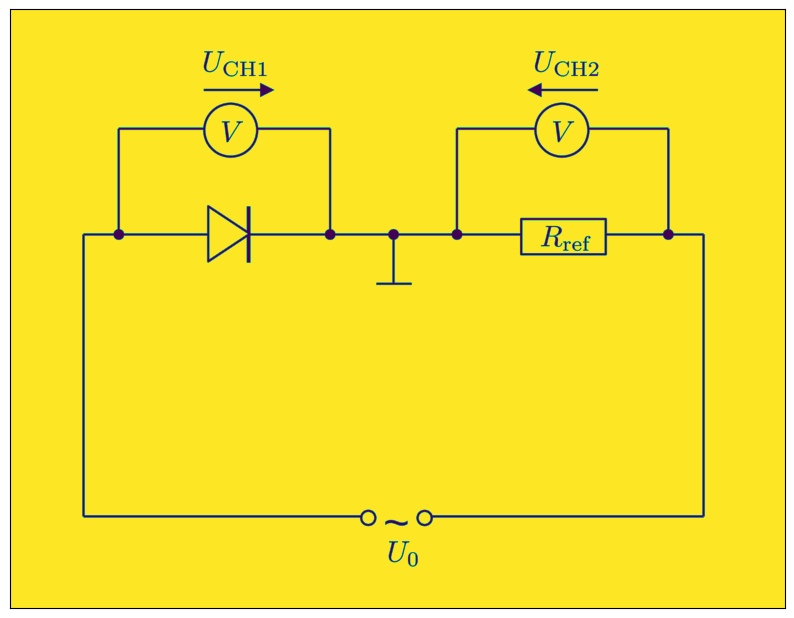

In [152]:
from os import getcwd
PWD=getcwd()

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = plt.figure("demo", figsize=(10.0, 10.0))
img = mpimg.imread("Messanordnung_Kennlinien.png".format(PWD=PWD))
imgplot = plt.imshow(img)
imgplot.axes.get_xaxis().set_visible(False)
imgplot.axes.get_yaxis().set_visible(False)
plt.show()

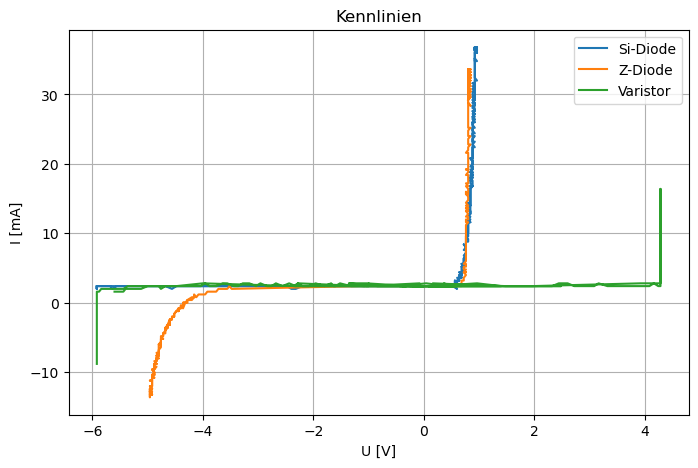

In [153]:
import pandas as pd
from uncertainties import unumpy as unp
from uncertainties import ufloat

U_abs_error = 0.04  # 0.04 V 
t_abs_error = 10**(-5) # 10 micro s
R_ref = ufloat(100, 2)

#Si diode einlesen
df = pd.read_csv("csv_data/Di16_1-1_SIdiode.csv")

time_Si = unp.uarray(df["Time"]*1000, t_abs_error) # in ms
ch1_u_Si = unp.uarray(df["CH1"], U_abs_error)
ch2_u_Si = unp.uarray(df["CH2"], U_abs_error)

I_Si = ch2_u_Si/R_ref

#Z Diode einlesen
df = pd.read_csv("csv_data/1-1_ZDiode.csv")

time_Z = unp.uarray(df["Time"]*1000, t_abs_error) # in ms
ch1_u_Z = unp.uarray(df["CH1"], U_abs_error)
ch2_u_Z = unp.uarray(df["CH2"], U_abs_error)

I_Z = ch2_u_Z/R_ref

# Varistor einlesen
df = pd.read_csv("csv_data/1-1_Varistor.csv")

time = unp.uarray(df["Time"]*1000, t_abs_error) # in ms
ch1_u_V = unp.uarray(df["CH1"], U_abs_error)
ch2_u_V = unp.uarray(df["CH2"], U_abs_error)

I_V = ch2_u_V/R_ref

# Plot
plt.figure(figsize=(8, 5))
plt.plot(unp.nominal_values(ch1_u_Si), unp.nominal_values(I_Si)*1000, label= "Si-Diode")
plt.plot(unp.nominal_values(ch1_u_Z), unp.nominal_values(I_Z)*1000, label= "Z-Diode")
plt.plot(unp.nominal_values(ch1_u_V), unp.nominal_values(I_V)*1000, label= "Varistor")

plt.xlabel("U [V]")
plt.ylabel("I [mA]")
plt.title("Kennlinien")
plt.grid(True)
plt.legend()

plt.show()

Die Kennlinien der drei zu untersuchenden Bauteile sind oben dargestellt. Nach Erreichen der Schwellspannung von ca. $U_S$ = 0.7 $\pm$ 0.1 V nimmt die Stromstärke bei der Si-Diode bzw. Z-Diode schlagartig zu. Bei Anlegen der Spannung in Sperrrichtung erkennt man bei der Z-Diode wieder einen starken Anstieg der Stromstärke. Die Durchbruchspannung bzw Zener-Spannung wurde als $U_{Z0}$ = 4.5 $\pm$ 0.5 V bestimmt. Die angelegte Spannung war zu klein, um die Durchbruchspannung der Si-Diode zu erkennen. Diese ist stark abhängig vom Modell und bei welcher Temperatur sie betrieben wird, aber müsste laut https://en.sorumatik.co/t/breakdown-voltage-of-silicon-diode/242282/2 bei 50 V bis 1000 V liegen, also weit über den Möglichkeiten unseres Versuchsaufbaus. 

Die Daten der Messung des Varistors zeigen kein typisches Verhalten. Der Varistor blockiert in beide Richtungen den Stromfluss bei kleinen Spannungen. Allerdings ist in negativer Spannungsrichtung die Schwellspannung bei ca. 6 V erreicht, wohingegen in positiver Spannungsrichtung die Schwellspannung schon bei ca. 4.3 V erreicht ist. Typisch für einen Varistor wäre ein punktsymmetrisches Verhalten. Die Gründe für dieses Verhalten sind  nur schwer zu bestimmen. Wenn man annimmt, dass das Verhalten des Varistors eigentlich typisch ist, ist möglicherweiße bei der Datenaufnahme eine Verschiebung der Daten aus CH1 passiert. Wenn das der Fall wäre, könnte man durch Verschiebung des Graphs in eine punktymmetrische Position die richtige Schwellspannung ablesen. Diese wäre in diesem Fall $U_S = \frac {5.9 + 4.3}{2} V = 5.1 \pm 0.5 V$.

Eine allgemeine Verschiebung in x-Richtung scheint nicht vorzuliegen, da die Schwellspannungen von $U_S$ = 0.7 $\pm$ 0.1 V recht typisch für Si-Dioden und Z-Dioden sind.

In der y-Achse scheint ein kleines Offset von wenigen mA anzuliegen. Dieses Offset wird allerdings als unphysikalisch bzw. durch fehlerhafte Einstellung bei der Datenaufnahme verursacht angenommen.

---

Zusätzlich wurde beim Bestimmen der Kennlinie der Si-Diode die Frequenz des Eingangssignals verändert, um das Verhalten zu beobachten. Die oben dargestellten Kennlinien wurden bei 100 Hz aufgenommen. Bei Hochregeln der Frequenz bildet sich eine Schleife auf der Seite der Durchlasspannung. Das liegt daran, dass eine reale Diode eine Kapazität hat. Diese sorgt dafür, dass die Stromstärke nun nicht mehr nur von dem gemessenen Spannungsabfall am Referenzwiderstand abhängt, sondern auch von der Änderungsrate der Spannung. Deshalb passen die bestimmten Stromstärken beim "Hochfahren" der Spannung nichtmehr zum "Herunterfahren" der Spannung und die Daten zeigen eine Schleifenbildung. Deshalb ist es wichtig bei der Bestimmung der Kennlinie von Dioden bei einer nicht zu hoch anliegenden Frequenz zu messen, da die Bestimmung der Stromstärke verfälscht wird.

<div class="alert alert-success" role="alert">

### Aufgabe 1.2: Leuchtdiode

 * Stellen Sie die **Kennlinie einer Leuchtdiode** dar. Hierzu stehen Ihnen Leuchtdioden unterschiedlicher Farbe zur Verfügung.
 * Sie können die Kennlinien mehrerer Leuchtdioden vermessen, für Ihre Auswertung genügt jedoch eine.

</div>

**V E R S U C H S B E S C H R E I B U N G**

Zur Aufnahme der Kennlinie einer roten Leuchtdiode (LED) wurde derselbe Versuchsaufbau wie in Aufgabe 1.1 verwendet.

Aus der aufgenommenen Kennlinie wurde die Schwellenspannung $U_{\mathrm{S}}$ bestimmt.

---

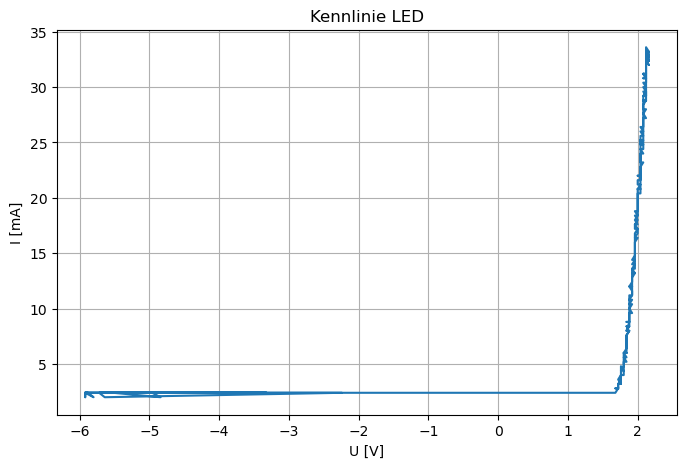

In [154]:
#LED einlesen
df = pd.read_csv("csv_data/1-2_LED.csv")

time_LED = unp.uarray(df["Time"]*1000, t_abs_error) # in ms
ch1_u_LED = unp.uarray(df["CH1"], U_abs_error)
ch2_u_LED = unp.uarray(df["CH2"], U_abs_error)

I_LED = ch2_u_LED/R_ref

# Plot
plt.figure(figsize=(8, 5))
plt.plot(unp.nominal_values(ch1_u_LED), unp.nominal_values(I_LED)*1000)

plt.xlabel("U [V]")
plt.ylabel("I [mA]")
plt.title("Kennlinie LED")
plt.grid(True)
#plt.legend()

plt.show()

Die Kennlinie der roten LED zeigt eine Schwellspannung $U_S$ von $\approx$ 2 $\pm$ 0.5 V. Ein Durchbruch in Sperrrichtung konnte nicht beobachtet werden, da die Durchbruchspannung kleiner als die erreichten -6 V ist. Das liegt aber auch im Sinne des Experiments, da das Erreichen der Durchbruchsspannung die LED wahrscheinlich beschädigen würde.

<div class="alert alert-success" role="alert">

### Aufgabe 1.3 Photodiode und Photowiderstand

 * Bestimmen Sie die **Kennlinien einer Photodiode** bei verschiedenen Beleuchtungsstärken $E_{\mathrm{V}}$.
 * Bestimmen Sie den den **Sperrstrom $I_{S}$ der gleichen Photodiode** als Funktion von $E_{\mathrm{V}}$.
 * Stellen Sie die **Kennlinien eines Photowiderstands** in beleuchtetem und abgedunkeltem Zustand dar und bestimmen Sie den jeweiligen Widerstand $R$.

</div>

**V E R S U C H S B E S C H R E I B U N G**

Zur Untersuchung des Photowiderstands und der Photodiode wurde derselbe Messaufbau wie in Aufgabe 1.1 verwendet. Die Versorgung erfolgte wieder durch den Frequenzgenerator, nur diesmal wurde eine sinusförmige Eingangsspannung von 50 Hz erzeugt.

Zunächst wurden die Kennlinien des Photowiderstands im beleuchteten und im abgedeckten Zustand aufgenommen. Aus den linearen Teil der Kennlinien wurde jeweils der Widerstand bestimmt.

Anschließend wurde die Photodiode mithilfe der Experimentierleuchte untersucht. Die Beleuchtungsstärke wurde durch Variation der Lampenspannung des Netzgeräts verändert. Für verschiedene Lampenspannungen wurden die Kennlinien der Photodiode aufgenommen und digital ausgelesen. Aus diesen Kennlinien wurde jeweils der Sperrstrom $I_S$ bestimmt und dessen Abhängigkeit von der Beleuchtungsstärke untersucht.

Sowohl Photodioden als auch Photowiderstände nutzen den inneren Photoeffekt. Trifft Licht auf das Halbleitermaterial, entstehen zusätzliche freie Ladungsträger (Elektron-Loch - Paare), wodurch die elektrische Leitfähigkeit zunimmt.

Bei der Photodiode führt dies zu einem lichtabhängigen Sperrstrom $I_S$, der mit steigender Beleuchtungsstärke zunimmt. Beim Photowiderstand sinkt dagegen der elektrische Widerstand mit zunehmender Beleuchtung.

---

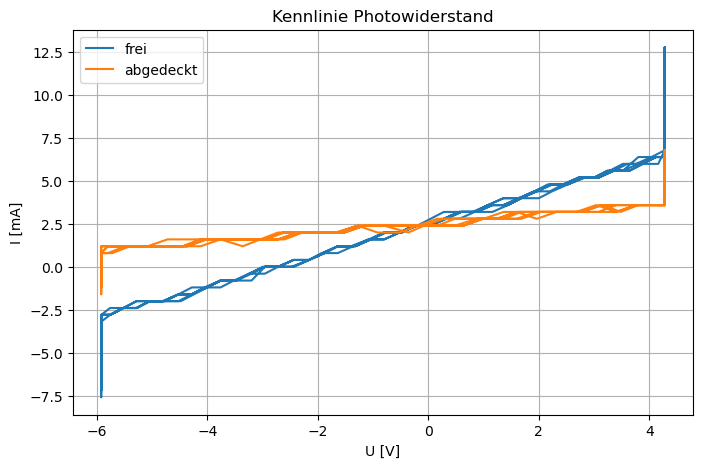

In [155]:
#Photowiderstand beleuchtet einlesen
df = pd.read_csv("csv_data/1-3_PT_frei.csv")

time_frei = unp.uarray(df["Time"]*1000, t_abs_error) # in ms
ch1_u_frei = unp.uarray(df["CH1"], U_abs_error)
ch2_u_frei = unp.uarray(df["CH2"], U_abs_error)

I_frei = ch2_u_frei/R_ref

#Photowiderstand abgedeckt einlesen
df = pd.read_csv("csv_data/1-3_PT_abgedeckt.csv")

time_abgedeckt = unp.uarray(df["Time"]*1000, t_abs_error) # in ms
ch1_u_abgedeckt = unp.uarray(df["CH1"], U_abs_error)
ch2_u_abgedeckt = unp.uarray(df["CH2"], U_abs_error)

I_abgedeckt = ch2_u_abgedeckt/R_ref

# Plot
plt.figure(figsize=(8, 5))
plt.plot(unp.nominal_values(ch1_u_frei), unp.nominal_values(I_frei)*1000, label= "frei")
plt.plot(unp.nominal_values(ch1_u_abgedeckt), unp.nominal_values(I_abgedeckt)*1000, label="abgedeckt")

plt.xlabel("U [V]")
plt.ylabel("I [mA]")
plt.title("Kennlinie Photowiderstand")
plt.grid(True)
plt.legend()

plt.show()

Gemäß dem Ohmschen Gesetz ist die Steigung der Graphen der Kehrwert des Widerstands. Die Daten wurden (nach Abschneiden der Ränder) im folgenden auf das Modell

$$
I = \frac{U}{R} + b
$$

gefittet, das Offset b ist wie in der 1.1 schon erwähnt als nicht physikalisch anzusehen.

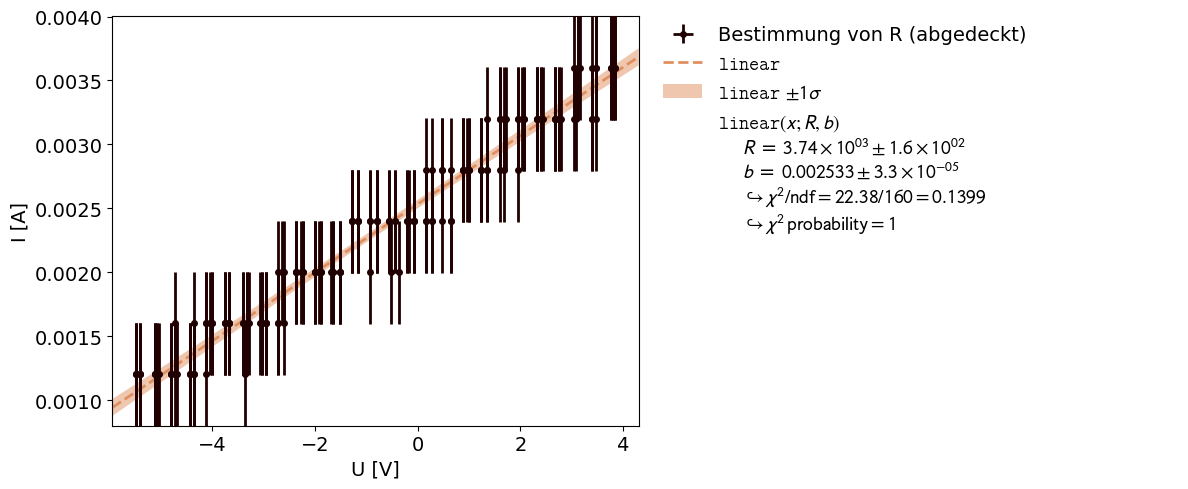

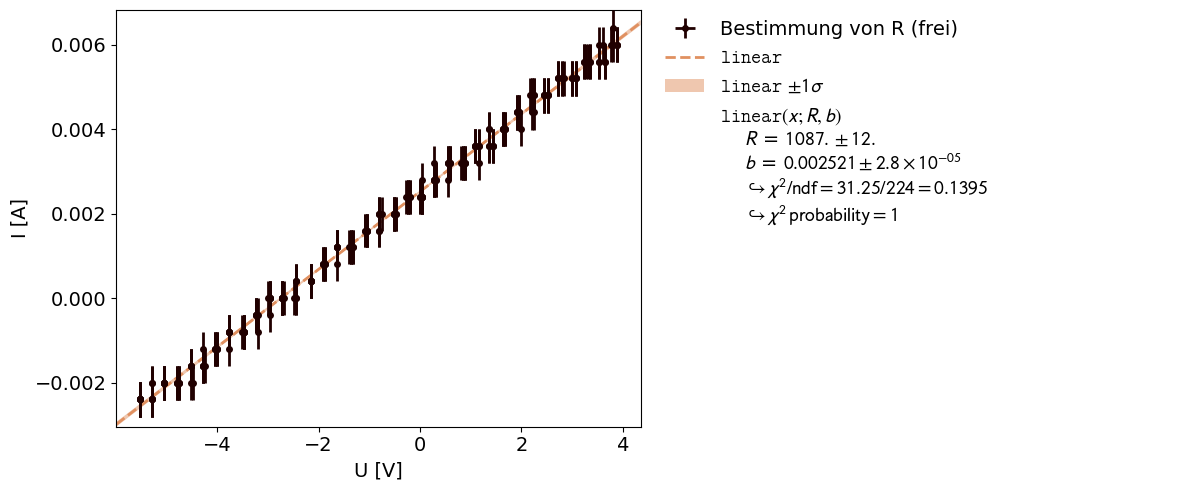

In [156]:
from kafe2 import config, XYContainer, Fit, XYFit,  Plot
import numpy as np

def linear(x, R, b):
    return x/R + b

# abschneiden der Ränder

mask_abgedeckt = (unp.nominal_values(ch1_u_abgedeckt) > -5.7) & (unp.nominal_values(ch1_u_abgedeckt) < 4.0)

ch1_abgedeckt_filtered = ch1_u_abgedeckt[mask_abgedeckt]
I_abgedeckt_filtered = I_abgedeckt[mask_abgedeckt]#A

mask_frei = (unp.nominal_values(ch1_u_frei) > -5.7) & (unp.nominal_values(ch1_u_frei) < 4.0)

ch1_frei_filtered = ch1_u_frei[mask_frei]
I_frei_filtered = I_frei[mask_frei]#A

# fit auf lineares Modell 
xy_data_abegdeckt = XYContainer(x_data=unp.nominal_values(ch1_abgedeckt_filtered), 
                      y_data=unp.nominal_values(I_abgedeckt_filtered)) 

xy_data_abegdeckt.add_error(
    axis='y',
    err_val=unp.std_devs(I_abgedeckt_filtered)
)  
xy_data_abegdeckt.add_error(
    axis='x', 
    err_val=unp.std_devs(ch1_abgedeckt_filtered)
) 
xy_data_abegdeckt.label = r'Bestimmung von R (abgedeckt)'

fit_abegdeckt = Fit(data=xy_data_abegdeckt, model_function=linear)

fit_abegdeckt.do_fit()

# plot the fit
plot = Plot(fit_objects=fit_abegdeckt)
plot.x_label = r'U [V]' 
plot.y_label = r'I [A]'

plot.plot()
plt.show()

# fit auf lineares Modell 
xy_data_frei = XYContainer(x_data=unp.nominal_values(ch1_frei_filtered), 
                      y_data=unp.nominal_values(I_frei_filtered)) 

xy_data_frei.add_error(
    axis='y',
    err_val=unp.std_devs(I_frei_filtered)
)  
xy_data_frei.add_error(
    axis='x', 
    err_val=unp.std_devs(ch1_frei_filtered)
) 
xy_data_frei.label = r'Bestimmung von R (frei)'

fit_frei = Fit(data=xy_data_frei, model_function=linear)

fit_frei.do_fit()

# plot the fit
plot = Plot(fit_objects=fit_frei)
plot.x_label = r'U [V]' 
plot.y_label = r'I [A]'

plot.plot()
plt.show()

Die Widerstände wurden folgendermaßen bestimmt:

$$
R_{\text{abgedeckt}} = 3720 \pm 160 \Omega, \, R_{\text{frei}} = 1087 \pm 12 \Omega
$$

Wie in der Versuchsbeschreibung erklärt, erhöht sich die Leitfähigkeit des Phototransistors bei mehr Lichteinfall. Dieses Verhalten deckt sich mit dem Ergebnis, dass der Widerstand bei höherem Lichteinfall kleiner ist. Man kann in den Daten sehr gut die Auflösung der Spannung bzw der ermittelten Stromstärke erkennen. Diese liegt bei 0.04 V bzw $\frac{0.04 \, V}{100 \, \Omega} = 0.4 \, \text{mA}$.

Das allgemeine Offset in der y-Richtung, das in allen Messwerten vorhanden ist, wurde in dem Fit als Parameter b mit $2.52 \pm 0.03 \, \text{mA}$ bestimmt.

---

Im folgenden wurde die Photodiode unter verschiedenen Bestrahlungsintensitäten getestet. Oberhalb der Durchbruchspannung kann die UI-Kennlinie einer Diode im Allgemeinen durch die Shockley-Gleichung beschrieben werden:

$$
I_F(U_F) = I_S(T)(e^{\frac{U_F}{n \, U_T}} - 1) \, \text{mit } U_F =  \frac{k_B \, T}{e}
$$

Wobei $I_S$ der Sperrstrom, $I_F (U_F)$ der Flussstrom (Flussspannung), $U_T$ die Temperaturspannung, $e$ die Elementarladung, $k_B$ die Boltzman-Konstante und $n$ der Emissionskoeffizient ist. $I_S$ ist hierbei eine Materialkonstante und sollte nicht von der Beleuchtung abhängen. Es wird dabei angenommen, dass die Photodiode sich nicht wirklich erwärmt, da die Beleuchtungszeit sehr gering war.

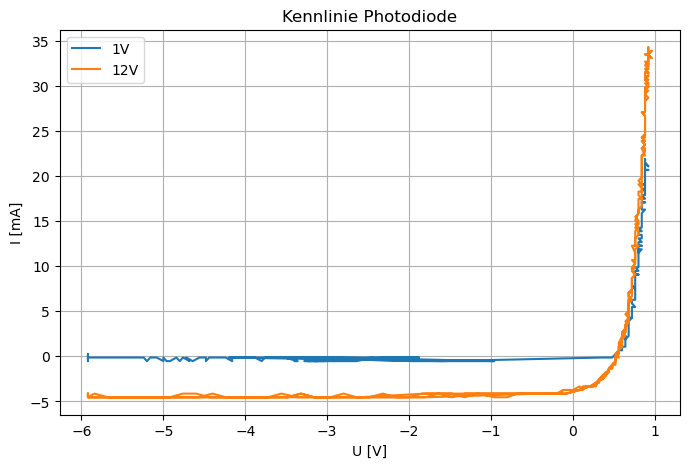

In [157]:
#Photodiode einlesen

ub = ufloat(0.00253, 0.00003)

 # 1V
df = pd.read_csv("csv_data/1-3_PD1V.csv")

ch1_1V = unp.uarray(df["CH1"], U_abs_error)
ch2_1V = unp.uarray(df["CH2"], U_abs_error)

I_1V = ch2_1V/R_ref - ub

# 12V
df = pd.read_csv("csv_data/1-3_PD12V.csv")

ch1_12V = unp.uarray(df["CH1"], U_abs_error)
ch2_12V = unp.uarray(df["CH2"], U_abs_error)

I_12V = ch2_12V/R_ref - ub

# Plot
plt.figure(figsize=(8, 5))
plt.plot(unp.nominal_values(ch1_1V), unp.nominal_values(I_1V)*1000, label= "1V")
plt.plot(unp.nominal_values(ch1_12V), unp.nominal_values(I_12V)*1000, label="12V")

plt.xlabel("U [V]")
plt.ylabel("I [mA]")
plt.title("Kennlinie Photodiode")
plt.grid(True)
plt.legend()

plt.show()

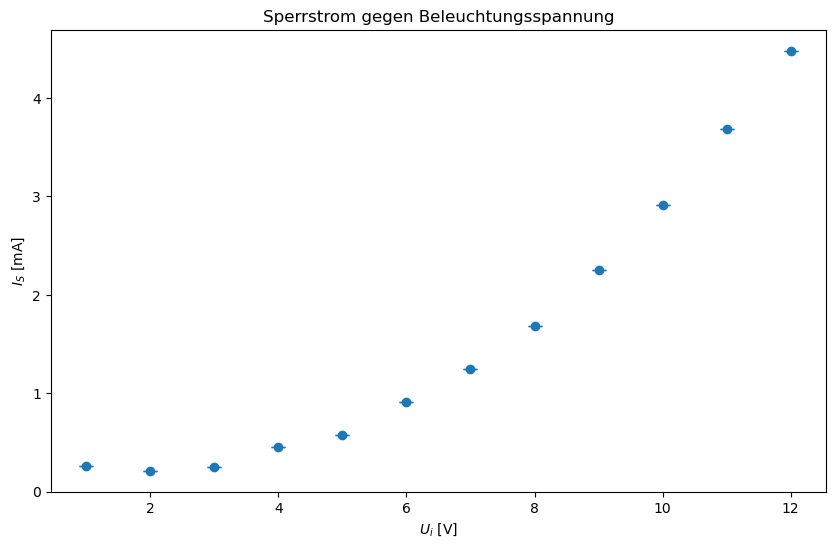

In [158]:
I_S = []

i = 1
while(i<=12):

    #einlesen
    df = pd.read_csv("csv_data/1-3_PD" + str(i)+"V.csv")

    ch1 = unp.uarray(df["CH1"], U_abs_error)
    ch2 = unp.uarray(df["CH2"], U_abs_error)

    I = ch2/R_ref - ub

    # verwende nur daten positiver spannung
    mask = (unp.nominal_values(ch1) < 0)

    #ch1_filtered = ch1[mask]
    I_filtered = I[mask]

    I_S = np.append(I_S, np.mean(I_filtered))

    i+=1


# Plot
U_i = [1, 2, 3, 4, 5,6, 7, 8, 9, 10, 11, 12]
# plot 
plt.figure(figsize=(10, 6))
plt.errorbar(U_i, - unp.nominal_values(I_S)*1000, yerr=unp.std_devs(I_S), fmt='o', capsize=5)

plt.xlabel(r'$U_i$ [V]')
plt.ylabel("$I_S$ [mA]")
plt.title("Sperrstrom gegen Beleuchtungsspannung")
plt.show()

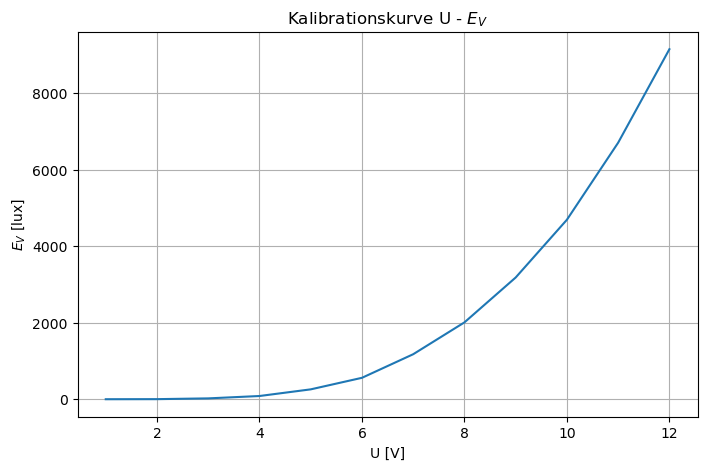

In [168]:
# Umrechnung U->Ev
df = pd.read_csv("params/Umrechnung_Lampenspannung.csv")

U = df["U (V)"]
Ev = df["E (lux)"]
diction = dict(zip(U, Ev))

Ev_plot = np.array([diction[u] for u in U_i])

# Plot
plt.figure(figsize=(8, 5))
plt.plot(U_i, Ev_plot)

plt.xlabel("U [V]")
plt.ylabel("$E_V$ [lux]")
plt.title("Kalibrationskurve U - $E_V$")
plt.grid(True)

plt.show()

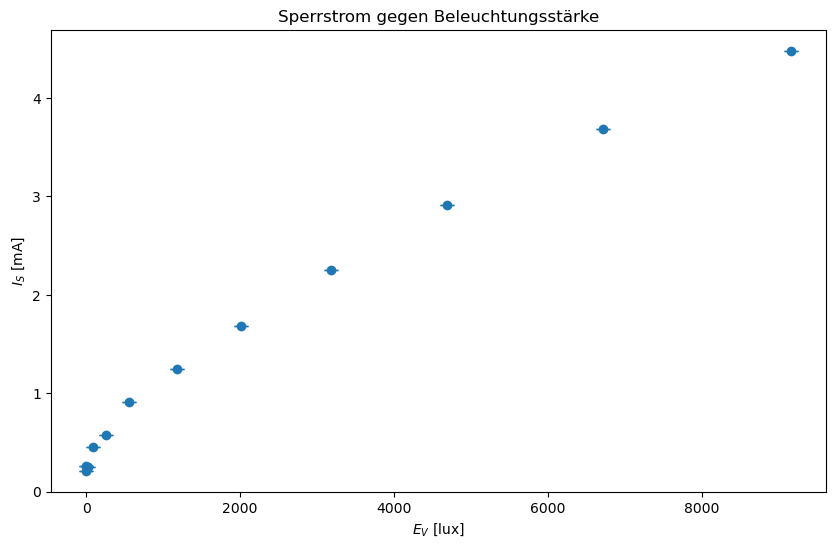

In [ ]:
# plot 
plt.figure(figsize=(10, 6))
plt.errorbar(Ev_plot, - unp.nominal_values(I_S)*1000, yerr=unp.std_devs(I_S), fmt='o', capsize=5)

plt.xlabel(r'$E_V$ [lux]')
plt.ylabel("$I_S$ [mA]")
plt.title("Sperrstrom gegen Beleuchtungsstärke")
plt.show()

**D I S K U S S I O N**

*Fügen Sie eine abschließende Diskussion und Bewertung Ihrer Lösung hier ein. Löschen Sie hierzu diesen kursiv gestellten Text aus dem Dokument.* 

---

<div class="alert alert-success" role="alert">
    
## Aufgabe 2: Eigenschaften von Leitern

</div>

<div class="alert alert-success" role="alert">

### Aufgabe 2.1: Abhängigkeit vom Druck

 * Führen Sie mit dem Oszilloskop qualitative Untersuchungen an verschiedenen **Piezoelementen** durch.

</div>

**V E R S U C H S B E S C H R E I B U N G**

In diesem Versuch wurde das Verhalten eines piezoelektrischen Elements bei mechanischer und elektrischer Anregung qualitativ untersucht. Dazu wurde das Piezoelement direkt an ein Oszilloskop angeschlossen und die entstehenden Spannungsverläufe beobachtet.

Im ersten Versuch wurde das Piezoelement durch Klopfen auf seine Oberfläche mechanisch belastet. Die dabei erzeugte Spannung wurde mit dem Oszilloskop aufgezeichnet.

Im zweiten Versuch wurde ein Lautsprecher mit einer sinusförmigen Spannung aus einem Funktionsgenerator betrieben. Das Piezoelement wurde auf den Lautsprecher gelegt, sodass die Schwingungen des Lautsprechers auf das Piezoelement übertragen wurden. Die erzeugte Spannung wurde in Abhängigkeit von der Anregungsfrequenz beobachtet.

Im dritten Versuch wurde das Piezoelement selbst an den Funktionsgenerator angeschlossen und elektrisch angeregt. Durch Variation der Frequenz wurde das Schwingungsverhalten des Piezoelements untersucht.

---

<div class="alert alert-success" role="alert">

### Aufgabe 2.2: Abhängigkeit von der Temperatur

 * Untersuchen Sie mit Hilfe eines Ofens die Abhängigkeiten der Widerstände eines (NTC) **Heissleiters** und eines (PTC) **Kaltleiters** von der Temperatur zwischen $\vartheta=60$ und $200^{\circ}\mathrm{C}$.

</div>

**V E R S U C H S B E S C H R E I B U N G**


In diesem Versuch wird die Abhängigkeit des elektrischen Widerstands von der Temperatur für einen PTC- und einen NTC-Widerstand im Bereich von $\vartheta = 20^{\circ}\mathrm{C}$ bis $200^{\circ}\mathrm{C}$ untersucht. Ziel ist der Vergleich eines metallischen Kaltleiters mit einem halbleitenden Heißleiter.

Als Kaltleiter wird ein PT100-Temperatursensor (PT100) verwendet, der bei $0^{\circ}\mathrm{C}$ einen Nennwiderstand von $R_0 = 100\,\Omega$ besitzt und einen nahezu linearen Temperaturkoeffizienten von $\alpha = 3.851 \cdot 10^{-3}\,°\mathrm{C}^{-1}$ aufweist. Der NTC besteht aus einem Metall-Oxid-Keramikwiderstand unbekannter Spezifikation.

Die Messung erfolgt mithilfe einer Wheatstoneschen Brückenschaltung (s. Skizze) bei einer Versorgungsspannung von $U_0 = 2\,\mathrm{V}$, wobei ein Multimeter im $\mathrm{mA}$-DC-Bereich als Brückeninstrument dient. Um Eigenerwärmung zu vermeiden, wird der Messstrom nur kurzzeitig zugeschaltet.

Zunächst wird die Kennlinie des NTC während des Aufheizens des Ofens von $20^{\circ}\mathrm{C}$ auf $200^{\circ}\mathrm{C}$ aufgenommen (15–20 Messpunkte). Anschließend erfolgt beim Abkühlen die Messung des PT100 im gleichen Temperaturbereich mit gleicher Messpunktanzahl.

Die Auswertung basiert auf der Darstellung von $R(\vartheta)$ inklusive Unsicherheiten. Für den PT100 wird ein linearer Zusammenhang 
$$
R(T) = R_0(1+\alpha T)
$$
gefittet, während der NTC mit einem exponentiellen Modell 
$$
\ln(R[\Omega])(T) = A (\frac{1}{T} - B)
$$ 
beschrieben wird. Hierbei sind C und C' zu bestimmende Konstanten.

---

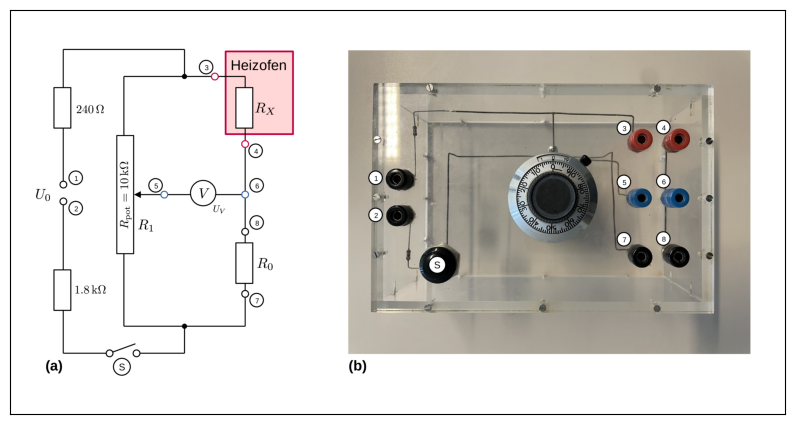

In [160]:
PWD=getcwd()

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = plt.figure("demo", figsize=(10.0, 10.0))
img = mpimg.imread("Messanordnung_Widerstand.png".format(PWD=PWD))
imgplot = plt.imshow(img)
imgplot.axes.get_xaxis().set_visible(False)
imgplot.axes.get_yaxis().set_visible(False)
plt.show()

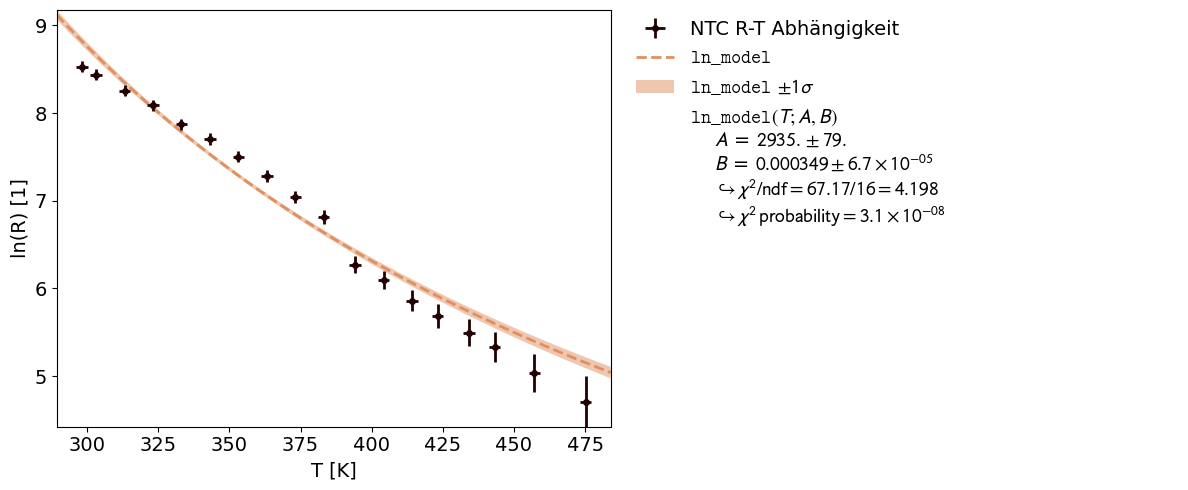

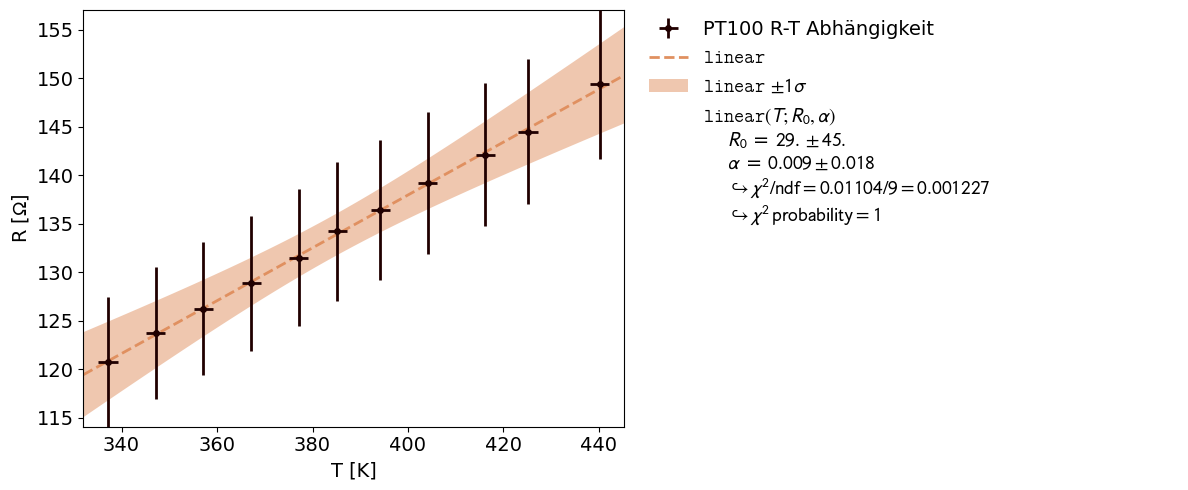

In [161]:
import numpy as np
from uncertainties import unumpy as unp
from uncertainties import ufloat
from kafe2 import config, XYContainer, Fit, XYFit,  Plot

# unsicherheiten von widerständen immer 5 prozent, temperatur 2 grad

un_T = 2
un_rel_R = 0.02
uR_pot = ufloat(10, 10*un_rel_R)*1000 #ohm

R1_NTC = np.array([1.65, 1.78, 2.065, 2.345, 2.76, 3.11, 3.55, 4.08, 4.66, 5.23, 6.54, 6.93, 7.40, 7.72, 8.04, 8.29, 8.67, 9.0])#kohm
uR1_NTC = unp.uarray(R1_NTC, R1_NTC*un_rel_R)*1000#ohm
uT_NTC = unp.uarray([25, 30, 40, 50, 60, 70, 80, 90, 100, 110, 121, 131, 141, 150, 161, 170, 184, 202], un_T) + 273.15#K
uR0_NTC = ufloat(1000, 50)#ohm

# am anfang mit falschen wiederstand gemessen deshalb erst ab 167 grad
R1_PT = np.array([4.01, 4.09, 4.13, 4.18, 4.23, 4.27, 4.32, 4.37, 4.42, 4.47, 4.53])#kohm
uR1_PT = unp.uarray(R1_PT, R1_PT*un_rel_R)*1000#ohm
uT_PT = unp.uarray([167, 152, 143, 131, 121, 112, 104, 94, 84, 74, 64], un_T) + 273.15#K
uR0_PT = ufloat(100, 100*un_rel_R)#ohm

#calculate Rx

uRx_NTC = (uR_pot - uR1_NTC) / uR1_NTC * uR0_NTC
uRx_PT =  (uR_pot - uR1_PT) / uR1_PT * uR0_PT

# Modell
def linear(T, R_0, alpha):
    return R_0*(1 + alpha * T)

# Modell
def ln_model(T, A, B):
    return A*(1/T - B)


uRx_ln = unp.log(uRx_NTC)

# fitting NTC
xy_data_NTC = XYContainer(x_data=unp.nominal_values(uT_NTC), 
                      y_data=unp.nominal_values(uRx_ln))

xy_data_NTC.add_error(
    axis='y', 
    err_val=unp.std_devs(uRx_ln)
)
xy_data_NTC.add_error(
    axis='x', 
    err_val=unp.std_devs(uT_NTC)
) 
xy_data_NTC.label = r'NTC R-T Abhängigkeit'

fit_NTC = Fit(data=xy_data_NTC, model_function=ln_model)

# constrain R0
#fit_NTC.add_parameter_constraint(name='R0',   value=unp.nominal_values(uR0_NTC),   uncertainty=unp.std_devs(uR0_NTC))

fit_NTC.do_fit()

# plot the fit
plot = Plot(fit_objects=fit_NTC)
plot.x_label = r'T [K]' 
plot.y_label = r'ln(R) [1]'

plot.plot()
plt.show()


# fitting PT100
xy_data_PT = XYContainer(x_data=unp.nominal_values(uT_PT), 
                      y_data=unp.nominal_values(uRx_PT)) 

xy_data_PT.add_error(
    axis='y', 
    err_val=unp.std_devs(uRx_PT)
)  
xy_data_PT.add_error(
    axis='x', 
    err_val=unp.std_devs(uT_PT)
) 
xy_data_PT.label = r'PT100 R-T Abhängigkeit'

fit_PT = Fit(data=xy_data_PT, model_function=linear)

# constrain R0
#fit_NTC.add_parameter_constraint(name='R0',   value=unp.nominal_values(uR0_NTC),   uncertainty=unp.std_devs(uR0_NTC))

fit_PT.do_fit()

# plot the fit
plot = Plot(fit_objects=fit_PT)
plot.x_label = r'T [K]' 
plot.y_label = r'R [$\Omega$]'

plot.plot()
plt.show()

**D I S K U S S I O N**

*Fügen Sie eine abschließende Diskussion und Bewertung Ihrer Lösung hier ein. Löschen Sie hierzu diesen kursiv gestellten Text aus dem Dokument.* 

---

<div class="alert alert-success" role="alert">

### Aufgabe 2.3: Hochtemperatursupraleitung

 * Bestimmen Sie die **Sprungtemperatur eines Hochtemperatursupraleiters**.

</div>

**V E R S U C H S B E S C H R E I B U N G**

In diesem Versuch wird die Sprungtemperatur $T_{\mathrm{C}}$ eines Hochtemperatursupraleiters bestimmt. Dazu wird der elektrische Widerstand des Materials in Abhängigkeit der Temperatur im Bereich von Raumtemperatur bis $77\,\mathrm{K}$ untersucht.

Die Messung erfolgt über eine Vierleiterschaltung, wodurch Kontakt- und Leitungswiderstände vernachlässigt werden können. Der eingespeiste Strom beträgt dabei konstant $I_0 = 63\,\mathrm{mA}$.

Der Spannungsabfall $U_R$ am Supraleiter wird mit einem Multimeter gemessen und zur Bestimmung des Widerstands verwendet.

Zur Temperaturvariation wird die Probe schrittweise von Raumtemperatur in ein Dewargefäß mit flüssigem Stickstoff abgesenkt. Dabei entsteht ein Temperaturgradient entlang der Halterung, weshalb die Position des Thermometers relativ zur Probe sorgfältig berücksichtigt werden muss. Insgesamt werden 20–25 Messpunkte $(U_{R,i}, T_i)$ in Schritten von etwa $5$–$10\,\mathrm{K}$ aufgenommen.

Für die Auswertung wird der Widerstand aus $R = U_R / I_0$ berechnet und als Funktion der Temperatur dargestellt. Als Unsicherheiten müssen zusätzlich eine Korrektur der Temperaturanzeige anhand der angegebenen Kalibrationstabelle berücksichtigt werden.

Die Sprungtemperatur $T_{\mathrm{C}}$ wird aus dem abrupten Abfall des Widerstands bestimmt. Dabei ist zu erwarten, dass durch den Temperaturgradienten zwischen Thermometer und Probe eine systematische Unsicherheit entsteht.

---

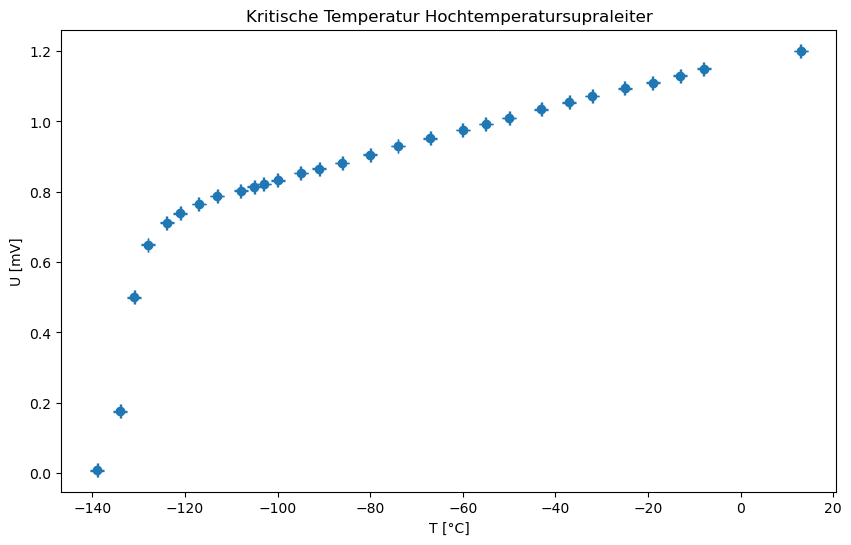

In [162]:
uT = unp.uarray([13, -8, -13, -19, -25, -32, -37, -43, -50, -55, -60, -67, -74, -80, -86, -91, -95, -100, -103, -105, -108, -139, -134, -131, -128, -124, -121, -117, -113], 0.1)#celsius
uU = unp.uarray([1.2, 1.15, 1.13, 1.11, 1.094, 1.072, 1.054, 1.034, 1.010, 0.993, 0.976, 0.952, 0.930, 0.905, 0.882, 0.866, 0.853, 0.833, 0.822, 0.815, 0.803, 0.008, 0.176, 0.500, 0.650, 0.712, 0.739, 0.765, 0.788], 0.001)#mV

# plot 
plt.figure(figsize=(10, 6))
plt.errorbar(unp.nominal_values(uT), unp.nominal_values(uU), xerr= unp.std_devs(uT), yerr=unp.std_devs(uU), fmt='o', capsize=5)
plt.xlabel("T [°C]")
plt.ylabel("U [mV]")
plt.title("Kritische Temperatur Hochtemperatursupraleiter")
plt.show()

**D I S K U S S I O N**

*Fügen Sie eine abschließende Diskussion und Bewertung Ihrer Lösung hier ein. Löschen Sie hierzu diesen kursiv gestellten Text aus dem Dokument.* 

---

# Beurteilung

 * Beurteilen Sie diesen Versuch nach Abschluss der Auswertung.
 * **Folgen Sie zur Beurteilung dieses Versuchs diesem [Link](https://www.empirio.de/s/UWm=UUYWWR)**.
 * Beachten Sie, dass jede:r Studierende nur einmal pro Versuch eine Beurteilung abgeben kann.

**Lösung:**

Fügen Sie Ihrem Protokoll einen Screenshot der letzten Informationsseite der oben verlinkten Beurteilung zu.